In [1]:
from agents.sql_agent import SQLAgent
from services.query_service import QueryService

In [2]:
agent = SQLAgent()

query_service = QueryService(
    "data/portfolio.db"
)

In [6]:
question = """
What is my largest holding?
"""

In [7]:
sql_query = agent.generate_sql(
    question
)

print(sql_query)

SELECT * FROM holdings ORDER BY market_value DESC LIMIT 1;


In [8]:
result = query_service.execute_query(
    sql_query
)

result

,symbol,company_name,isin,market_cap,sector,quantity,avg_trading_price,invested_value,market_value,overall_gain_loss,holding_weightage
0,BHARATFORG,Bharat Forge,INE465A01025,MidCap,Castings/Forgings,17,1421.59,24167,33063,8896.27,11.73


In [9]:
def ask_portfolio(question):

    sql_query = (
        agent.generate_sql(question)
    )

    result = (
        query_service.execute_query(
            sql_query
        )
    )

    return result

In [10]:
ask_portfolio(
    "Which stock has highest profit?"
)

,symbol,company_name,overall_gain_loss
0,SBC,SBC Exports,10224.9


In [4]:
from agents.sql_orchestrator import (
    SQLOrchestrator
)

orchestrator = SQLOrchestrator(
    "data/portfolio.db"
)

In [5]:
response = orchestrator.ask(
    "Give me the portfolio summary"
)

In [6]:
response = orchestrator.ask(
    "Who is the prime minister of India?"
)

In [3]:
response["sql"]

'SELECT symbol, company_name, market_value\nFROM holdings\nORDER BY market_value DESC\nLIMIT 5;'

In [7]:
response["result"]

,total_quantity,total_invested_value,total_market_value,total_gain_loss,average_holding_weightage
0,1572,276371,281997,5616.28,5.265263


In [6]:
response

{'status': 'success',
 'sql': 'SELECT SUM(quantity) AS total_quantity, SUM(invested_value) AS total_invested_value, SUM(market_value) AS total_market_value, SUM(overall_gain_loss) AS total_gain_loss, AVG(holding_weightage) AS average_holding_weightage FROM holdings;',
 'result':    total_quantity  total_invested_value  total_market_value  total_gain_loss  \
 0            1572                276371              281997          5616.28   
 
    average_holding_weightage  
 0                   5.265263  }

### Analytics Engine

In [8]:
from analytics.portfolio_analytics import (
    PortfolioAnalytics
)

analytics = PortfolioAnalytics(
    "data/portfolio.db"
)

In [9]:
analytics.get_portfolio_summary()

{'total_holdings': 19,
 'total_market_value': np.int64(281997),
 'total_invested_value': np.int64(276371),
 'total_gain_loss': np.float64(5616.280000000001)}

In [10]:
analytics.get_top_holdings()

,symbol,market_value
18,BHARATFORG,33063
8,MANAPPURAM,28294
15,SBC,26147
11,ANANDRATHI,22110
12,ABB,21822


In [11]:
analytics.get_sector_allocation()

,sector,market_value,allocation_pct
5,Finance/NBFC,69663,26.52
2,Castings/Forgings,33063,12.59
11,Textile,26147,9.95
4,Electric Equipment,21822,8.31
10,Steel/Sponge Iron/Pig Iron,21353,8.13
9,Port,19411,7.39
8,Mining & Minerals,18404,7.01
3,Defence,16174,6.16
6,IT - Software,15406,5.86
7,Logistics,11068,4.21


In [12]:
from agents.portfolio_assistant import (
    PortfolioAssistant
)

assistant = PortfolioAssistant(
    "data/portfolio.db"
)

In [13]:
assistant.ask(
    "Show portfolio summary"
)

{'total_holdings': 19,
 'total_market_value': np.int64(281997),
 'total_invested_value': np.int64(276371),
 'total_gain_loss': np.float64(5616.280000000001)}

In [14]:
assistant.ask(
    "Which sector dominates my portfolio?"
)

,sector,market_value,allocation_pct
5,Finance/NBFC,69663,26.52
2,Castings/Forgings,33063,12.59
11,Textile,26147,9.95
4,Electric Equipment,21822,8.31
10,Steel/Sponge Iron/Pig Iron,21353,8.13
9,Port,19411,7.39
8,Mining & Minerals,18404,7.01
3,Defence,16174,6.16
6,IT - Software,15406,5.86
7,Logistics,11068,4.21


In [18]:
question = "yes"

response = assistant.ask(question)

print(response)

{'status': 'rejected', 'message': 'Please ask portfolio related questions.'}


In [19]:
from graph.portfolio_graph import workflow

In [21]:
graph = workflow.compile()

ValueError: Graph must have an entrypoint: add at least one edge from START to another node

### check langgraph agent

In [1]:
from graph.portfolio_graph import (
    portfolio_graph
)



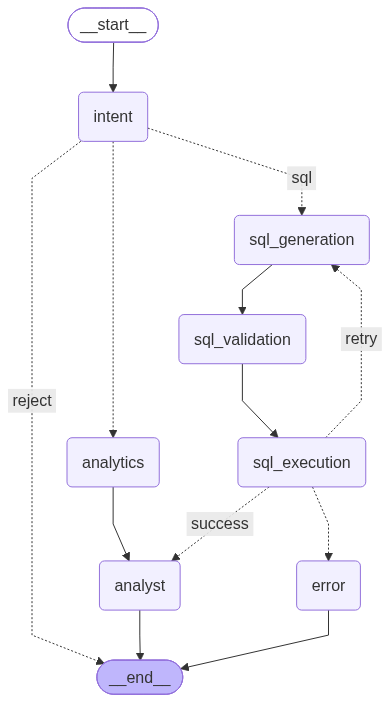

In [2]:
portfolio_graph

In [3]:
response = portfolio_graph.invoke(
    {
        "question":
            "What is my portfolio summary?",

        "intent": None,
        "sql_query": None,
        "raw_result": None,
        "explanation": None,
        "retry_count": 0,
        "error": None
    }
)

In [8]:
response = portfolio_graph.invoke(
    {
        "question":
            "Show top 5 holdings by market value",

        "intent": None,
        "sql_query": None,
        "raw_result": None,
        "explanation": None,
        "retry_count": 0,
        "error": None
    }
)

In [9]:
print(response["explanation"])

Here are the top 5 holdings by market value:

1. **Bharat Forge (BHARATFORG)**
   - **Market Value:** ₹33,063
   - **Sector:** Castings/Forgings
   - **Quantity Held:** 17 shares
   - **Overall Gain/Loss:** ₹8,896.27
   - **Weight in Portfolio:** 11.73%

2. **Manappuram Finance (MANAPPURAM)**
   - **Market Value:** ₹28,294
   - **Sector:** Finance/NBFC
   - **Quantity Held:** 86 shares
   - **Overall Gain/Loss:** ₹4,019.64
   - **Weight in Portfolio:** 10.04%

3. **SBC Exports (SBC)**
   - **Market Value:** ₹26,147
   - **Sector:** Textile
   - **Quantity Held:** 541 shares
   - **Overall Gain/Loss:** ₹10,224.90
   - **Weight in Portfolio:** 9.27%

4. **Anand Rathi Wealth (ANANDRATHI)**
   - **Market Value:** ₹22,110
   - **Sector:** Finance/NBFC
   - **Quantity Held:** 10 shares
   - **Overall Gain/Loss:** ₹4,167.60
   - **Weight in Portfolio:** 7.84%

5. **A B B (ABB)**
   - **Market Value:** ₹21,822
   - **Sector:** Electric Equipment
   - **Quantity Held:** 3 shares
   - **Overall 

In [10]:
response

{'question': 'Show top 5 holdings by market value',
 'intent': 'sql',
 'sql_query': 'SELECT * FROM holdings ORDER BY market_value DESC LIMIT 5;',
 'raw_result':        symbol      company_name          isin market_cap              sector  \
 0  BHARATFORG      Bharat Forge  INE465A01025     MidCap   Castings/Forgings   
 1  MANAPPURAM   Manappuram Fin.  INE522D01027   SmallCap        Finance/NBFC   
 2         SBC       SBC Exports  INE04AK01028   SmallCap             Textile   
 3  ANANDRATHI  Anand Rathi Wea.  INE463V01026   SmallCap        Finance/NBFC   
 4         ABB             A B B  INE117A01022   LargeCap  Electric Equipment   
 
    quantity  avg_trading_price  invested_value  market_value  \
 0        17            1421.59           24167         33063   
 1        86             282.26           24274         28294   
 2       541              29.43           15922         26147   
 3        10            1794.24           17942         22110   
 4         3            675

In [11]:
response = portfolio_graph.invoke(
    {
        "question":
            "What is the stock price of apple?",
    }
)

In [12]:
response

{'question': 'What is the stock price of apple?', 'intent': 'reject'}